# Task 2.2 — CNN Image Classifier
**Week 2 | Skillset Go EduTech AI/ML Track**

A convolutional neural network in PyTorch trained on the **Optical Recognition of Handwritten Digits** image dataset
(1,797 grayscale 8x8 images, 10 classes), which ships with scikit-learn. The pipeline — image preparation, a
conv/pool/fully-connected architecture, training, and evaluation — is the same one used for larger image
sets such as histopathology tiles.

## 1. Prepare the image dataset

train=1257  val=270  test=270  image shape=(8, 8)


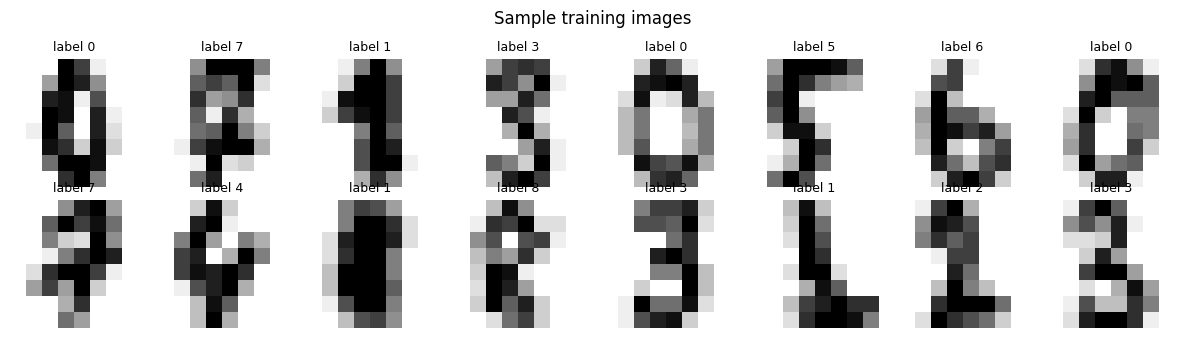

In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt, time
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42); np.random.seed(42)

digits = load_digits()
images = (digits.images / 16.0).astype('float32')       # 1797 x 8 x 8, scaled to [0,1]
labels = digits.target.astype('int64')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(images, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)        # add channel dim -> (N,1,8,8)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class SimpleCNN(nn.Module):
    def __init__(self, c1=16, c2=32, p_drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, c1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 8x8 -> 4x4
            nn.Conv2d(c1, c2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 4x4 -> 2x2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(c2 * 2 * 2, 64), nn.ReLU(), nn.Dropout(p_drop), nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def evaluate(model, loader):
    model.eval(); correct, total, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            loss_sum += crit(out, yb).item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item(); total += len(yb)
    return loss_sum / total, correct / total

train_loader = DataLoader(ImageDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(ImageDataset(X_val, y_val), batch_size=128)
test_loader  = DataLoader(ImageDataset(X_te, y_te), batch_size=128)
print(f"train={len(y_tr)}  val={len(y_val)}  test={len(y_te)}  image shape={X_tr.shape[1:]}")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, lab in zip(axes.ravel(), X_tr[:16], y_tr[:16]):
    ax.imshow(img, cmap='gray_r'); ax.set_title(f'label {lab}', fontsize=9); ax.axis('off')
plt.suptitle('Sample training images'); plt.tight_layout(); plt.savefig('cnn_samples.png', dpi=110); plt.show()

## 2. CNN architecture

In [2]:
model = SimpleCNN()
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
trainable parameters: 13706


## 3. Train

epoch  1 | train loss 2.2924 | val loss 2.2714 | val acc 0.1074


epoch  5 | train loss 1.3081 | val loss 1.0061 | val acc 0.8111


epoch 10 | train loss 0.4208 | val loss 0.3434 | val acc 0.9037


epoch 15 | train loss 0.2481 | val loss 0.2135 | val acc 0.9296


epoch 20 | train loss 0.1768 | val loss 0.1586 | val acc 0.9630


epoch 25 | train loss 0.1187 | val loss 0.1287 | val acc 0.9630


epoch 30 | train loss 0.0895 | val loss 0.0998 | val acc 0.9704
training time: 1.8s


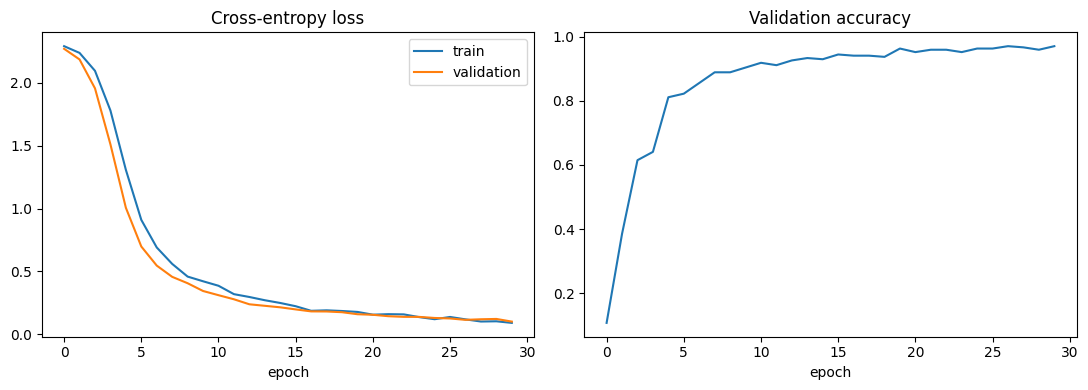

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
hist = {'train_loss': [], 'val_loss': [], 'val_acc': []}

t0 = time.time()
for epoch in range(1, 31):
    model.train(); loss_sum = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); optimizer.step()
        loss_sum += loss.item() * len(yb)
    vl, va = evaluate(model, val_loader)
    hist['train_loss'].append(loss_sum / len(y_tr)); hist['val_loss'].append(vl); hist['val_acc'].append(va)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d} | train loss {hist['train_loss'][-1]:.4f} | val loss {vl:.4f} | val acc {va:.4f}")
print(f"training time: {time.time() - t0:.1f}s")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='validation')
ax[0].set_title('Cross-entropy loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist['val_acc']); ax[1].set_title('Validation accuracy'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig('cnn_training_curves.png', dpi=110); plt.show()

## 4. Accuracy report (test set)

Test loss = 0.0889 | Test accuracy = 0.9741

               precision    recall  f1-score   support

           0      1.000     1.000     1.000        27
           1      0.931     0.964     0.947        28
           2      0.963     1.000     0.981        26
           3      1.000     1.000     1.000        28
           4      1.000     0.963     0.981        27
           5      1.000     1.000     1.000        27
           6      0.963     0.963     0.963        27
           7      0.964     1.000     0.982        27
           8      0.957     0.846     0.898        26
           9      0.964     1.000     0.982        27

    accuracy                          0.974       270
   macro avg      0.974     0.974     0.973       270
weighted avg      0.974     0.974     0.974       270



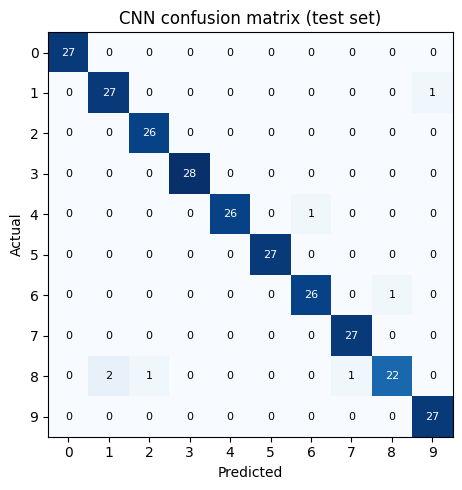

Saved trained model -> cnn_digits.pt


In [4]:
test_loss, test_acc = evaluate(model, test_loader)
print(f"Test loss = {test_loss:.4f} | Test accuracy = {test_acc:.4f}")

model.eval()
with torch.no_grad():
    Xt = torch.from_numpy(X_te).unsqueeze(1)
    pred = model(Xt).argmax(1).numpy()
print("\n", classification_report(y_te, pred, digits=3))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8, color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_title('CNN confusion matrix (test set)')
plt.tight_layout(); plt.savefig('cnn_confusion_matrix.png', dpi=110); plt.show()

torch.save(model.state_dict(), 'cnn_digits.pt')
print("Saved trained model -> cnn_digits.pt")

## Summary
A two-block convolutional network (conv -> ReLU -> max-pool, twice, then a fully connected head with dropout) was
trained with cross-entropy loss and Adam. Its test accuracy, per-class precision/recall, and confusion matrix are
reported above; the trained weights are saved as `cnn_digits.pt` for reuse in Task 2.3.